# TabPFN-3 SCM Prior (Tabular Data)

## What is a tabular foundation model?

A **tabular foundation model** is a pretrained predictor for heterogeneous tables — mixed numeric / categorical columns, missing entries, and a schema that changes from task to task — rather than for images or text. Models in the TabPFN family treat a labelled table as an in-context prompt and produce predictions for new rows in a single forward pass, without per-dataset gradient descent.

[TabPFN-3](https://arxiv.org/abs/2605.13986) (Prior Labs Team, 2026) is pretrained **only** on synthetic tables. That avoids leakage from real benchmarks, but it requires a prior that is broad enough to look like real tabular data: causal dependence among columns, hidden confounders, class structure after discretization, outliers, missingness, and mixed types. Section 2.5 of the technical report describes that prior as a **structural causal model (SCM)** over a sampled DAG. This notebook walks through S2Generator's reproduction, `SCMPriorPipeline`.

## Core principle of the SCM prior

The paper's design goal is to *maximize the breadth of possible datasets while capturing the structure models will encounter in the real world*. Each training table is drawn from the five-step procedure in Figure 9:

1. **Sample hyperparameters.** Draw the table size — number of rows $N$, observed features $P$, and (optionally) classes $C$ — together with graph-related knobs.
2. **Sample a DAG.** A directed acyclic graph $G=(V,E)$ is drawn with one of several graph algorithms (chain, fork, collider, random, scale-free, bipartite). In parallel, an i.i.d. noise process $\varepsilon_i$ is assigned to every node.
3. **Compute the SCM.** Root (exogenous) nodes are filled with noise. Remaining nodes are evaluated in topological order by combining their parents and adding their own noise,
   $$
   X_i = f_i\bigl(\mathrm{pa}(X_i)\bigr) + \varepsilon_i.
   $$
   The map $f_i$ is a randomly chosen combiner (linear, MLP, polynomial, ...) composed with an activation.
4. **Extract the dataset.** A subset of nodes becomes the observed feature matrix $X$; one node is reserved as the target $Y$; the rest stay **hidden**. Hidden nodes still influence $X$ and $Y$, so the observed table is only a partial view of the causal system.
5. **Post-process.** Observational transforms (outliers, missing values, per-column scale/shift, quantile binning into categoricals) make the table look less like a clean simulation.

<p align="center">
<img width="75%" align="middle" src="../../docs/source/_static/TabPFN.jpg">
</p>
<p align="center"><em>Figure 9 of TabPFN-3: sample hyperparameters, sample DAG, compute the SCM in topological order, extract $X$ / $Y$ / hidden nodes, then post-process into a synthetic table.</em></p>

Reference: Prior Labs Team (2026). *TabPFN-3: Technical Report*. [arXiv:2605.13986](https://arxiv.org/abs/2605.13986).


## What `generate` actually returns

`SCMPriorPipeline.generate` is **not** a time-series sampler. Each of the $N$ rows is an independent draw from the same SCM (one observational unit), and each of the $P$ columns is one **observed** node of the graph.

| `n_classes` | Return value | Shapes | Meaning |
| --- | --- | --- | --- |
| omitted (`None`) | `X` | `(N, P)` | unsupervised feature table |
| integer $C \ge 2$ | `(X, y)` | `X`: `(N, P)`, `y`: `(N,)` `int64` | supervised table; $y \in \{0,\dots,C-1\}$ |
| either, plus `return_metadata=True` | `..., metadata` | dict | graph size, feature/target node ids, edge list, ... |

- **$X$** is `float64` (or the pipeline `dtype`). After post-processing it may contain `NaN` (missingness) and some columns may be integer-valued categorical bins.
- **$y$** is obtained by quantile-binning one SCM node into $C$ balanced classes (TabPFN-3 many-class target). It is **not** written into $X$; keep it as a separate vector, or pass `(X, y)` to `save_table` to append it as a last column.
- **Hidden nodes** appear in `metadata["n_nodes"]` and `edge_list` but not in $X$. That is intentional: the paper uses them as unobserved confounders.
- Rows are exchangeable. Plotting $X$ against the row index is only a convenience for inspecting column scales; there is no temporal order.

Use `save_table` (`s2generator.utils`) to write the same arrays as `.csv` or `.xlsx`.


In [1]:
%matplotlib inline
import os
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))

from s2generator.scm import SCMPriorPipeline
from s2generator.utils import plot_graph, plot_adjacency_matrix, save_table


def adjacency_from_edges(n_nodes, edge_list):
    """Rebuild a (V, V) adjacency matrix from metadata['edge_list'] (parent -> child)."""
    adj = np.zeros((n_nodes, n_nodes), dtype=int)
    for parent, child in edge_list:
        adj[int(parent), int(child)] = 1
    return adj


rng = np.random.RandomState(0)
pipe = SCMPriorPipeline(Vmin=8, Vmax=16, apply_postprocessing=False)

print("dag algorithms:", pipe.dag_algorithms)
print("combiner mechanisms:", pipe.combiner_mechanisms)
print("activations:", pipe.activations)

dag algorithms: ['chain', 'fork', 'collider', 'random', 'scale_free', 'bipartite']
combiner mechanisms: ['linear', 'mlp', 'polynomial', 'multiplicative', 'periodic', 'maxmin']
activations: ['relu', 'sigmoid', 'tanh', 'sin', 'gelu', 'softplus', 'identity', 'high_freq_sin']


## A small unsupervised table ($X$ only)

Without `n_classes`, `generate` returns only the feature matrix. We wrap it in a `DataFrame` so the $(N, P)$ layout is obvious: **rows = samples, columns = features**.


In [2]:
X_small = pipe.generate(rng, n_samples=12, n_features=4)
print("X shape:", X_small.shape, " dtype:", X_small.dtype)
pd.DataFrame(X_small, columns=[f"x{j}" for j in range(X_small.shape[1])])

X shape: (12, 4)  dtype: float64


,x0,x1,x2,x3
0,0.177494,0.424773,1.0,-1.038754
1,-0.901405,-0.119763,0.0,0.785331
2,-0.843376,1.129304,0.0,-0.629500
3,0.812330,-0.499911,2.0,-0.427671
4,1.239041,0.035164,1.0,-1.070136
5,-0.322752,0.107877,1.0,0.988075
6,0.694078,-0.238680,0.0,-0.325230
7,-0.182093,-0.553743,0.0,0.785202
8,0.651066,0.321260,2.0,0.161179
9,0.230994,0.746870,2.0,-0.183815


## A small supervised table $(X, y)$

Passing `n_classes` quantile-bins a target node. Class counts are nearly balanced by construction.


In [3]:
X, y = pipe.generate(rng, n_samples=200, n_features=4, n_classes=3)
print("X shape:", X.shape, " y shape:", y.shape, " y dtype:", y.dtype)
print("class counts:", dict(enumerate(np.bincount(y))))

df_xy = pd.DataFrame(X, columns=[f"x{j}" for j in range(X.shape[1])])
df_xy["target"] = y
df_xy.head()

X shape: (200, 4)  y shape: (200,)  y dtype: int64
class counts: {0: np.int64(67), 1: np.int64(66), 2: np.int64(67)}


,x0,x1,x2,x3,target
0,0.470919,0.953128,-0.830695,-3.057955,1
1,0.298891,0.877976,2.653383,0.568857,2
2,-0.678623,0.024702,0.714811,-0.794696,1
3,-0.556256,1.036295,2.069532,1.268521,0
4,-1.299007,-0.997762,1.544299,0.859242,2


## Custom DAG

A user-supplied adjacency matrix (`adjacency[i, j] = 1` means $i \to j$) replaces the random graph sampler. Here we force a chain $0 \to 1 \to \cdots \to 5$. Features and the target are still read off randomly from the nodes; the remaining nodes stay hidden.


feature nodes: [2, 3, 4, 5]
target node: 1
hidden nodes: [0]


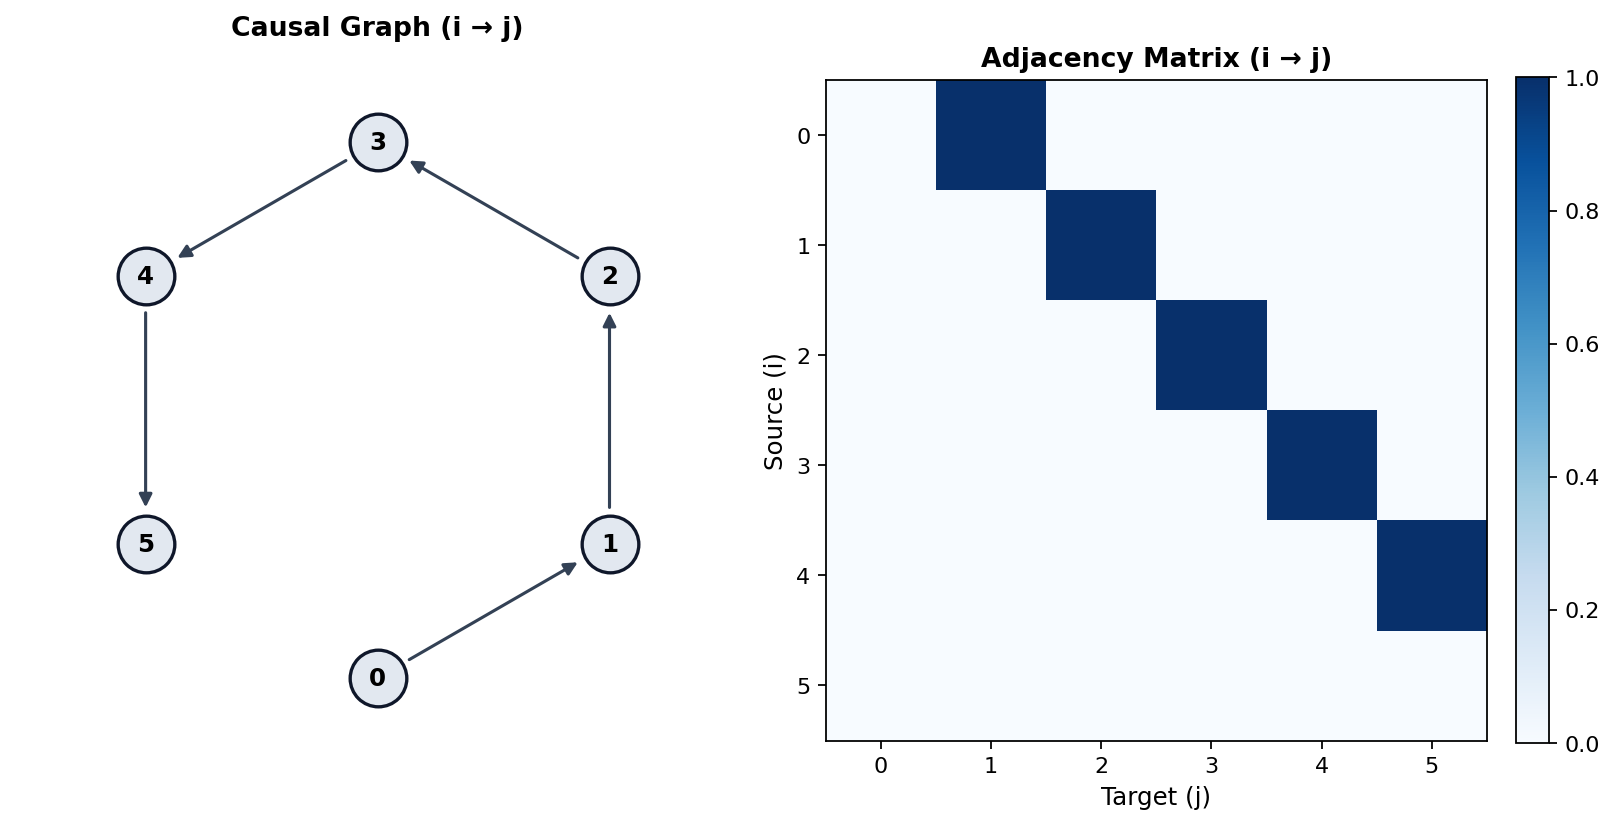

In [4]:
V = 6
adj_chain = np.zeros((V, V), dtype=int)
for i in range(V - 1):
    adj_chain[i, i + 1] = 1

X_chain, y_chain, meta_chain = pipe.generate(
    rng,
    n_samples=256,
    n_features=4,
    n_classes=3,
    adjacency=adj_chain,
    return_metadata=True,
)
print("feature nodes:", meta_chain["feature_nodes"])
print("target node:", meta_chain["target_node"])
print(
    "hidden nodes:",
    sorted(
        set(range(V)) - set(meta_chain["feature_nodes"]) - {meta_chain["target_node"]}
    ),
)

plot_graph(adj_chain, show_matrix=True)
plt.show()

## Metadata of a random graph

`return_metadata=True` records which nodes were observed. Reconstructing the adjacency matrix lets us see the causal skeleton that generated the table — including hidden nodes.


{'n_rows': 256, 'n_features': 5, 'n_classes': 4, 'n_nodes': 15, 'n_edges': 14, 'n_roots': 1, 'graph_source': 'random'}
feature_nodes: [0, 4, 6, 8, 10]
target_node: 11
root_nodes: [0]


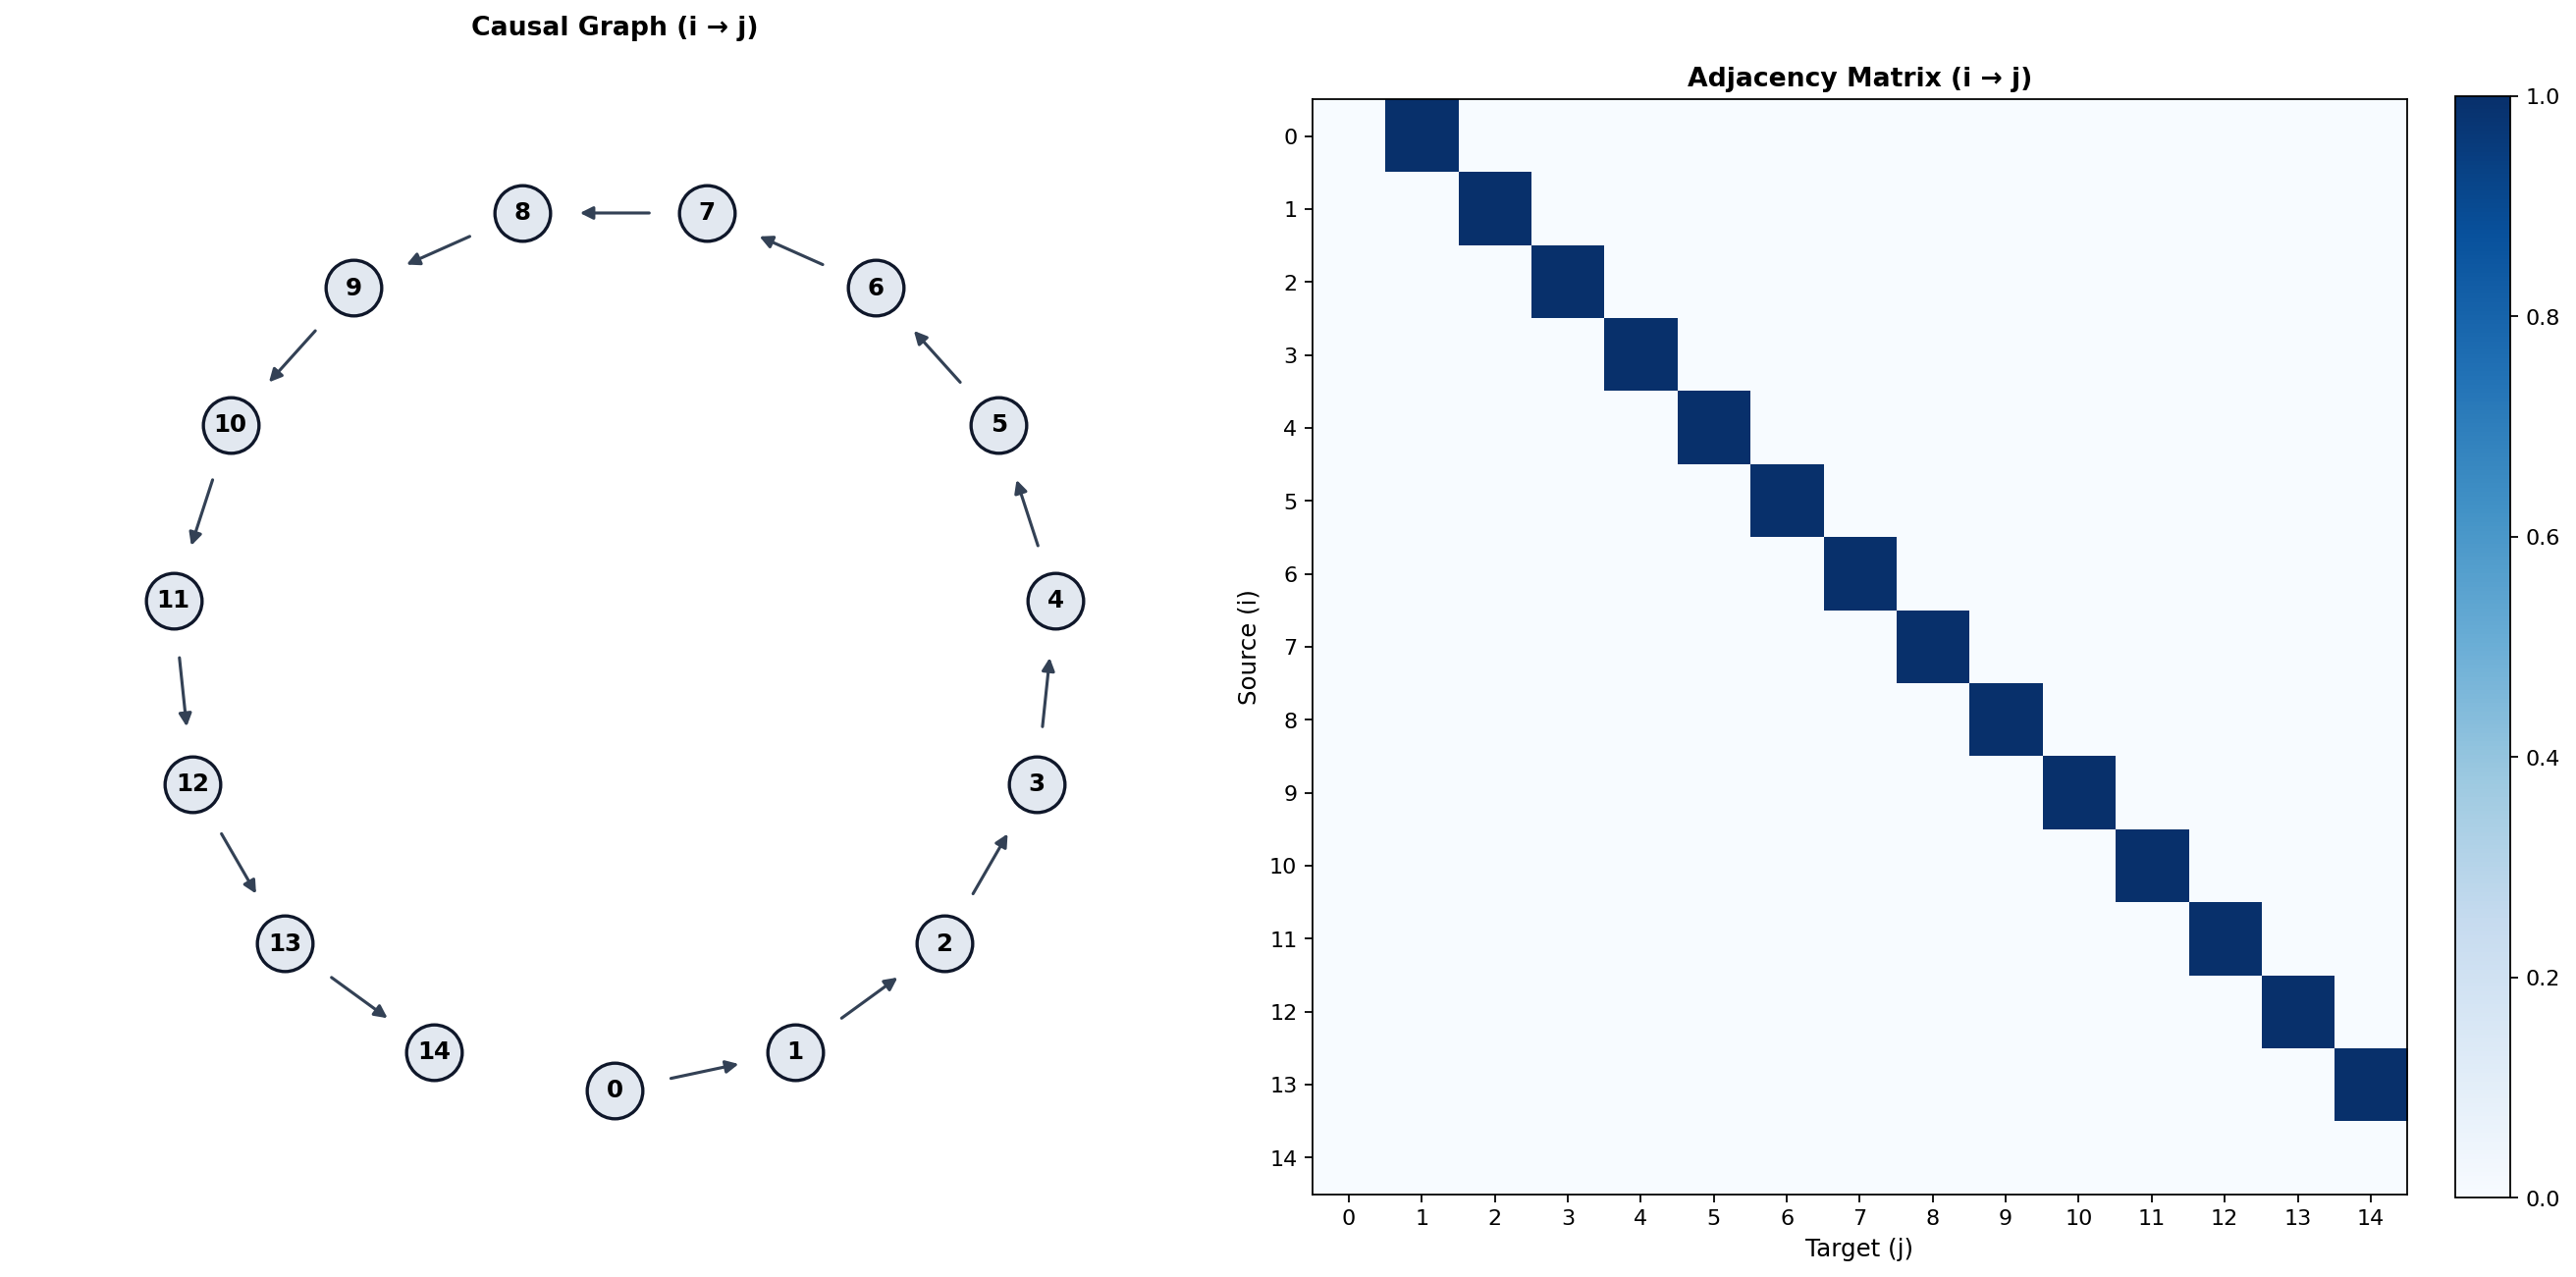

In [5]:
X_m, y_m, meta = pipe.generate(
    rng, n_samples=256, n_features=5, n_classes=4, return_metadata=True
)
print(
    {
        k: meta[k]
        for k in (
            "n_rows",
            "n_features",
            "n_classes",
            "n_nodes",
            "n_edges",
            "n_roots",
            "graph_source",
        )
    }
)
print("feature_nodes:", meta["feature_nodes"])
print("target_node:", meta["target_node"])
print("root_nodes:", meta["root_nodes"])

adj_rand = adjacency_from_edges(meta["n_nodes"], meta["edge_list"])
plot_graph(adj_rand, show_matrix=True)
plt.show()

## How the generated table looks

Because rows are i.i.d. observational samples, we inspect **column geometry** rather than a time axis: class-coloured scatter of two features, per-feature histograms, and the Pearson correlation of the observed columns. Dependence among features is inherited from shared parents / paths in the DAG, not from a shared time index.


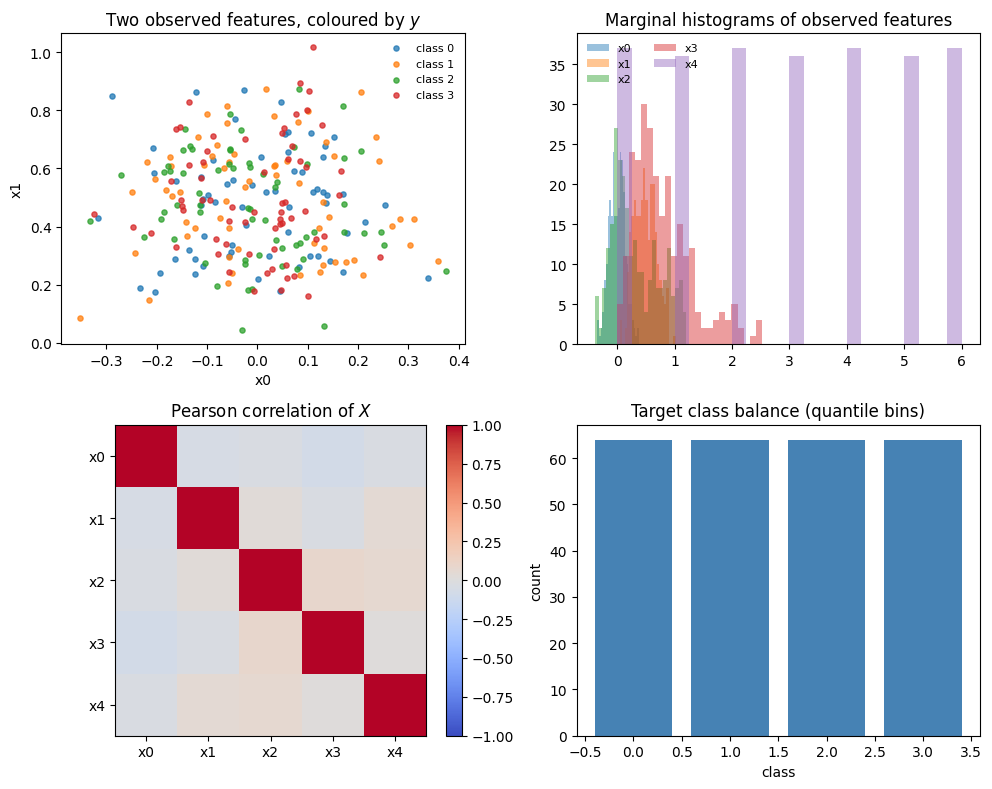

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

ax = axes[0, 0]
for cls in np.unique(y_m):
    mask = y_m == cls
    ax.scatter(X_m[mask, 0], X_m[mask, 1], s=14, alpha=0.75, label=f"class {cls}")
ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.set_title("Two observed features, coloured by $y$")
ax.legend(frameon=False, fontsize=8)

ax = axes[0, 1]
for j in range(X_m.shape[1]):
    ax.hist(X_m[:, j], bins=24, alpha=0.45, label=f"x{j}")
ax.set_title("Marginal histograms of observed features")
ax.legend(frameon=False, fontsize=8, ncol=2)

ax = axes[1, 0]
corr = np.corrcoef(X_m, rowvar=False)
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(X_m.shape[1]))
ax.set_yticks(range(X_m.shape[1]))
ax.set_xticklabels([f"x{j}" for j in range(X_m.shape[1])])
ax.set_yticklabels([f"x{j}" for j in range(X_m.shape[1])])
ax.set_title("Pearson correlation of $X$")
fig.colorbar(im, ax=ax, fraction=0.046)

ax = axes[1, 1]
counts = np.bincount(y_m)
ax.bar(np.arange(len(counts)), counts, color="steelblue")
ax.set_xlabel("class")
ax.set_ylabel("count")
ax.set_title("Target class balance (quantile bins)")

fig.tight_layout()
plt.show()

## Post-processing (step 5)

With `apply_postprocessing=True` the pipeline randomly injects outliers, missing values, and per-column scale/shift (and may quantile-bin some columns into categoricals). That is the paper's last stage: the raw SCM values are turned into a table that looks observational.


NaN rate:         0.0875
categorical nodes: [4]
column min / max:
 [[-1.31709904 -5.54728392 -2.21503328 -1.12798859  0.         -0.0376261 ]
 [ 9.19296884  6.63917952  3.49268117  2.21675958  1.          7.23282082]]


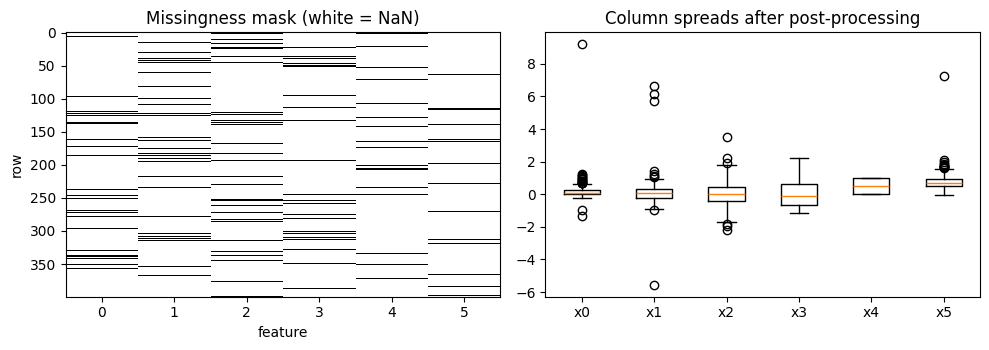

In [7]:
pipe_pp = SCMPriorPipeline(
    Vmin=8, Vmax=16, apply_postprocessing=True, categorical_prob=0.35
)
X_pp, y_pp, meta_pp = pipe_pp.generate(
    rng, n_samples=400, n_features=6, n_classes=3, return_metadata=True
)

print("NaN rate:        ", float(np.isnan(X_pp).mean()))
print("categorical nodes:", meta_pp["categorical_features"])
print(
    "column min / max:\n", np.vstack([np.nanmin(X_pp, axis=0), np.nanmax(X_pp, axis=0)])
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].imshow(np.isnan(X_pp), aspect="auto", cmap="Greys", interpolation="nearest")
axes[0].set_xlabel("feature")
axes[0].set_ylabel("row")
axes[0].set_title("Missingness mask (white = NaN)")

finite = X_pp.copy()
col_med = np.nanmedian(finite, axis=0)
inds = np.where(np.isnan(finite))
finite[inds] = np.take(col_med, inds[1])
axes[1].boxplot(
    [finite[:, j] for j in range(finite.shape[1])],
    tick_labels=[f"x{j}" for j in range(finite.shape[1])],
)
axes[1].set_title("Column spreads after post-processing")
fig.tight_layout()
plt.show()

## Large-scale tables

Pre-training needs many rows and moderately wide schemas, not just toy $(200 \times 4)$ matrices. `n_samples` / `n_features` are bounded by the DAG size: with a target, at most $V-1$ columns can be extracted, so raise `Vmin` / `Vmax` when you want a wide table.

Below we draw two datasets:

- **medium** — $N=2000$ rows, $P=16$ features, $C=5$ classes;
- **large** — $N=8000$ rows, $P=40$ features, $C=10$ classes (closer to a pre-training draw).


In [8]:
pipe_large = SCMPriorPipeline(
    Vmin=42,
    Vmax=60,
    Pmax=6,
    apply_postprocessing=False,
)

t0 = time.perf_counter()
X_med, y_med, meta_med = pipe_large.generate(
    rng, n_samples=2000, n_features=16, n_classes=5, return_metadata=True
)
t_med = time.perf_counter() - t0

t0 = time.perf_counter()
X_large, y_large, meta_large = pipe_large.generate(
    rng, n_samples=8000, n_features=40, n_classes=10, return_metadata=True
)
t_large = time.perf_counter() - t0

summary = pd.DataFrame(
    [
        {
            "name": "medium",
            "N": X_med.shape[0],
            "P": X_med.shape[1],
            "C": int(y_med.max()) + 1,
            "V": meta_med["n_nodes"],
            "E": meta_med["n_edges"],
            "seconds": round(t_med, 3),
        },
        {
            "name": "large",
            "N": X_large.shape[0],
            "P": X_large.shape[1],
            "C": int(y_large.max()) + 1,
            "V": meta_large["n_nodes"],
            "E": meta_large["n_edges"],
            "seconds": round(t_large, 3),
        },
    ]
)
summary

,name,N,P,C,V,E,seconds
0,medium,2000,16,5,45,48,0.425
1,large,8000,40,10,42,135,3.514


large X dtype: float64  y dtype: int64
large class counts: [800 800 800 800 800 800 800 800 800 800]
             x0      x1        x2        x3        x4        x5        x6  \
count  8000.000  8000.0  8000.000  8000.000  8000.000  8000.000  8000.000   
mean      2.000     3.0     0.187     0.129     0.753     0.527     1.147   
std       1.414     2.0     0.457     0.235     0.371     0.698     1.341   
min       0.000     0.0    -0.475    -0.352    -0.061    -0.349    -0.346   
25%       1.000     1.0    -0.121    -0.024     0.419     0.013     0.261   
50%       2.000     3.0     0.033     0.068     0.699     0.206     0.703   
75%       3.000     5.0     0.361     0.208     1.101     0.956     1.542   
max       4.000     6.0     3.614     1.388     1.634     5.349    16.717   

             x7  
count  8000.000  
mean      0.499  
std       0.192  
min      -0.167  
25%       0.365  
50%       0.496  
75%       0.633  
max       1.158  


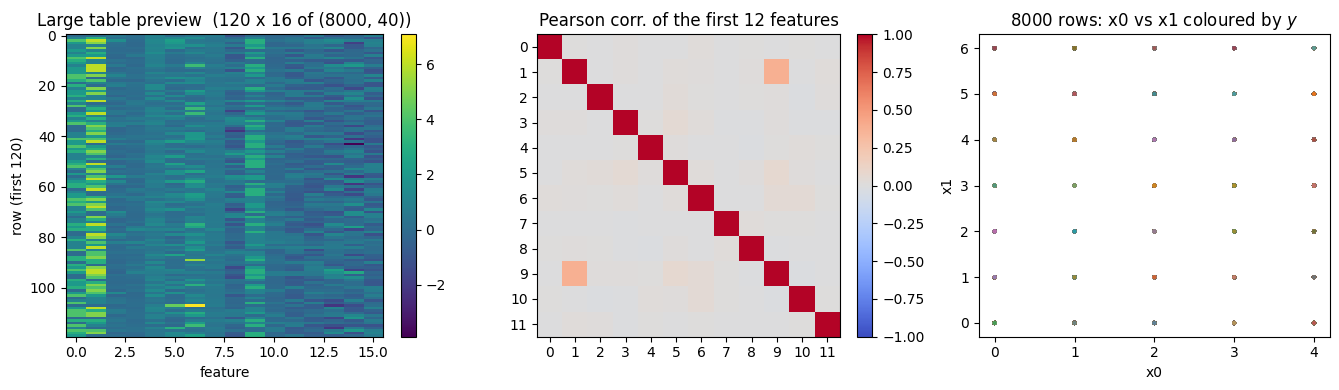

In [9]:
print("large X dtype:", X_large.dtype, " y dtype:", y_large.dtype)
print("large class counts:", np.bincount(y_large))
print(
    pd.DataFrame(X_large[:, :8], columns=[f"x{j}" for j in range(8)])
    .describe()
    .round(3)
)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))

ax = axes[0]
show_p = 16
im = ax.imshow(
    X_large[:120, :show_p], aspect="auto", cmap="viridis", interpolation="nearest"
)
ax.set_xlabel("feature")
ax.set_ylabel("row (first 120)")
ax.set_title(f"Large table preview  (120 x {show_p} of {X_large.shape})")
fig.colorbar(im, ax=ax, fraction=0.046)

ax = axes[1]
corr = np.corrcoef(X_large[:, :12], rowvar=False)
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Pearson corr. of the first 12 features")
ax.set_xticks(range(12))
ax.set_yticks(range(12))
fig.colorbar(im, ax=ax, fraction=0.046)

ax = axes[2]
ax.scatter(X_large[:, 0], X_large[:, 1], c=y_large, s=4, alpha=0.35, cmap="tab10")
ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.set_title("8000 rows: x0 vs x1 coloured by $y$")

fig.tight_layout()
plt.show()

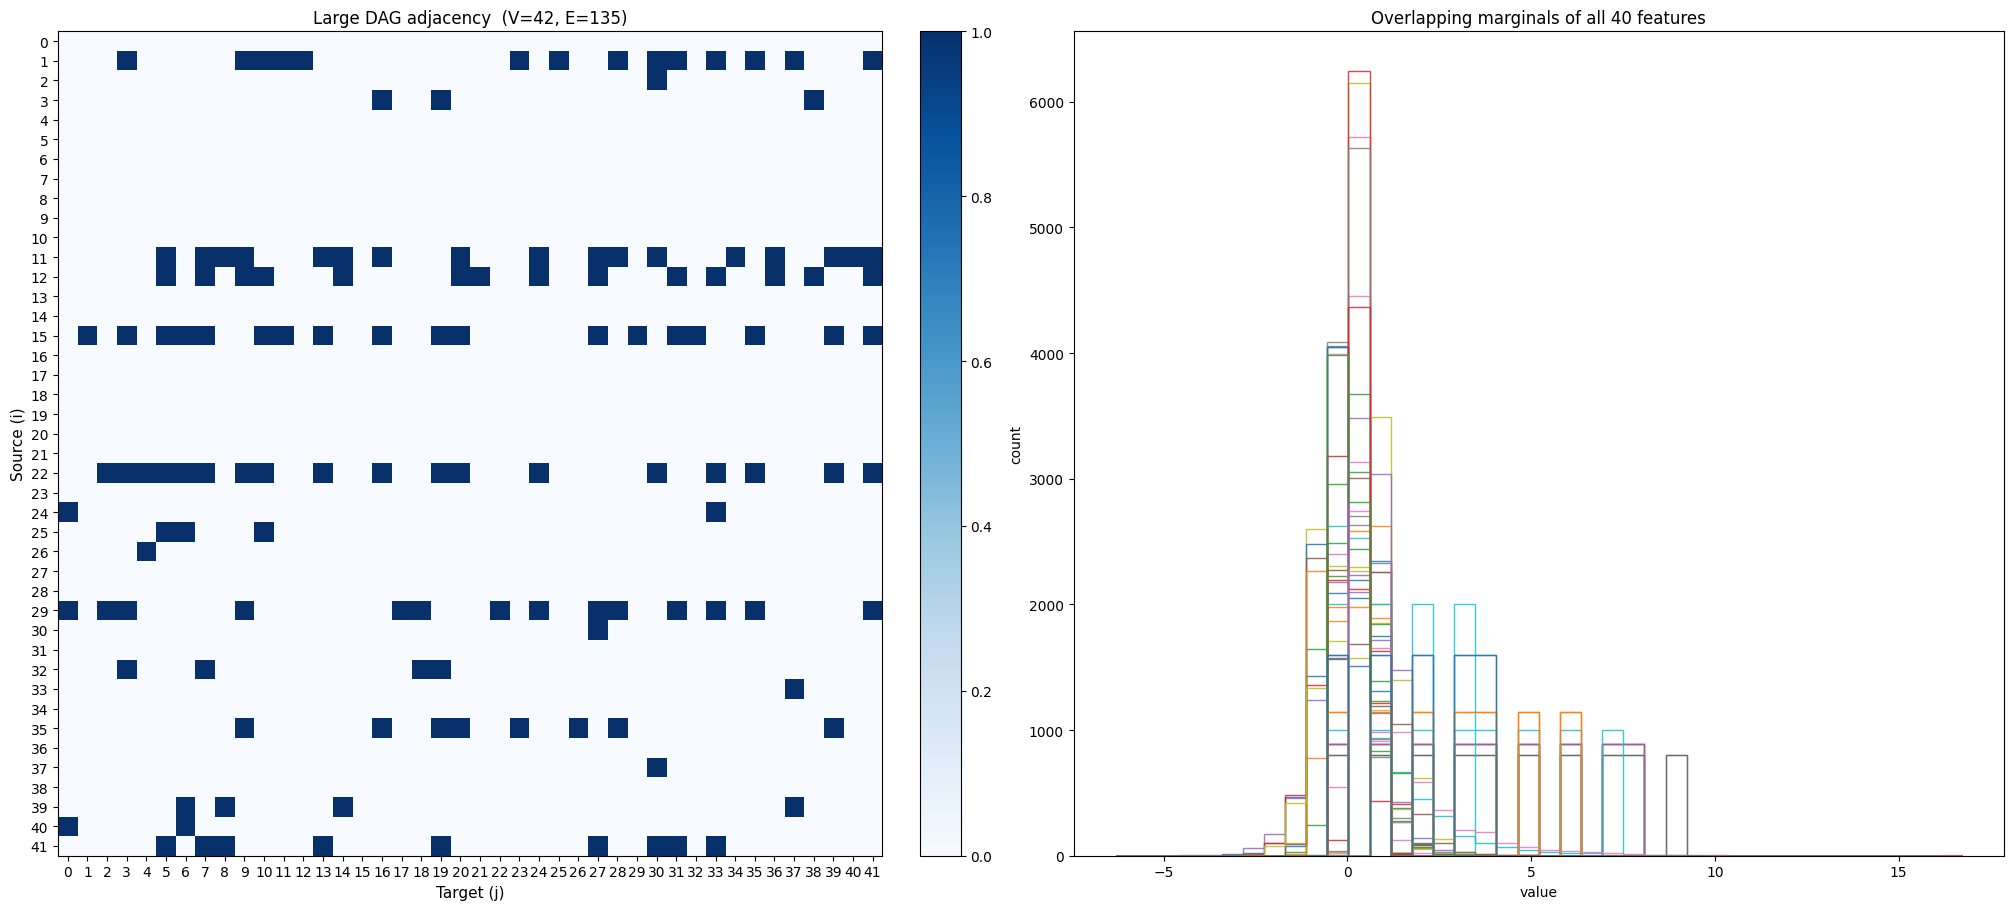

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(20.5, 9.2))

adj_large = adjacency_from_edges(meta_large["n_nodes"], meta_large["edge_list"])
plot_adjacency_matrix(adj_large, ax=axes[0])
axes[0].set_title(
    f"Large DAG adjacency  (V={meta_large['n_nodes']}, E={meta_large['n_edges']})"
)

axes[1].hist(X_large, bins=40, histtype="step", alpha=0.85)
axes[1].set_title("Overlapping marginals of all 40 features")
axes[1].set_xlabel("value")
axes[1].set_ylabel("count")

fig.tight_layout()
plt.show()

## A batch of independent tables

Pre-training iterates over many independent SCM draws. `generate_batch` returns a list of `(X, y)` pairs (or `X` arrays when `n_classes` is omitted).


n datasets: 6
  [0] X=(512, 10)  y=(512,)  classes=[128, 128, 128, 128]
  [1] X=(512, 10)  y=(512,)  classes=[128, 128, 128, 128]
  [2] X=(512, 10)  y=(512,)  classes=[128, 128, 128, 128]
  [3] X=(512, 10)  y=(512,)  classes=[128, 128, 128, 128]
  [4] X=(512, 10)  y=(512,)  classes=[128, 128, 128, 128]
  [5] X=(512, 10)  y=(512,)  classes=[128, 128, 128, 128]


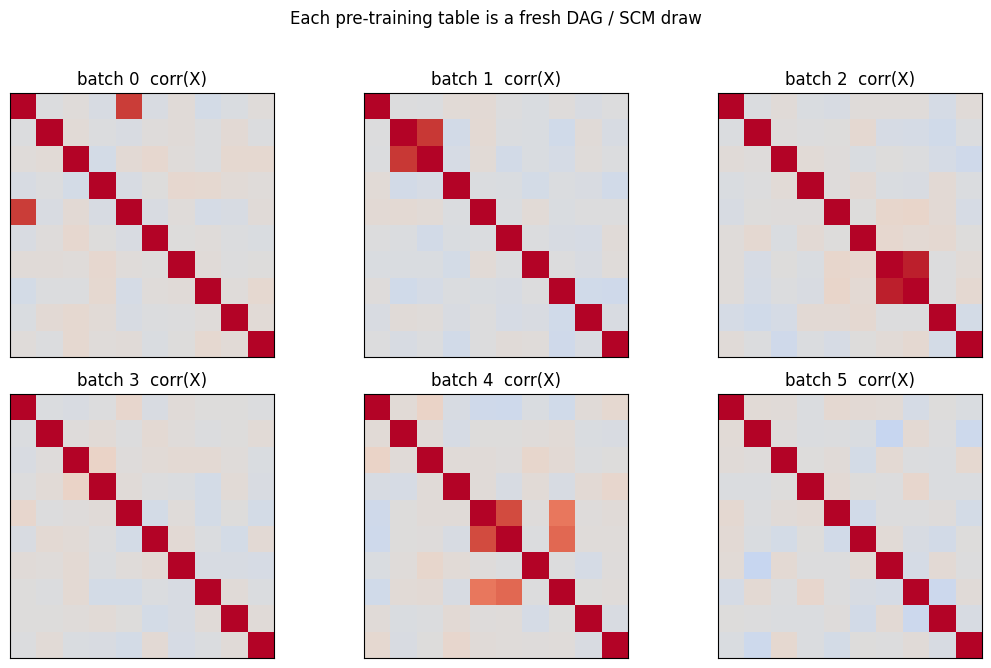

In [11]:
batch = pipe_large.generate_batch(
    rng, n_batches=6, n_samples=512, n_features=10, n_classes=4
)
print("n datasets:", len(batch))
for i, (Xb, yb) in enumerate(batch):
    print(f"  [{i}] X={Xb.shape}  y={yb.shape}  classes={np.bincount(yb).tolist()}")

fig, axes = plt.subplots(2, 3, figsize=(11, 6.5), sharex=False, sharey=False)
for i, (Xb, yb) in enumerate(batch):
    ax = axes[i // 3][i % 3]
    corr = np.corrcoef(Xb, rowvar=False)
    ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(f"batch {i}  corr(X)")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Each pre-training table is a fresh DAG / SCM draw", y=1.02)
fig.tight_layout()
plt.show()

## Save as CSV / Excel

`save_table` writes the same `(N, P)` (plus optional $y$) layout to disk:

- `.csv` — UTF-8 spreadsheet, no extra dependency;
- `.xlsx` — Excel workbook (needs `openpyxl`).

Pass the `(X, y)` tuple from `generate`, or `X` plus `y=...`. Feature names default to `x0, x1, ...`; the target column defaults to `target`.


In [12]:
out_dir = os.path.abspath(os.path.join(".", "_generated"))
os.makedirs(out_dir, exist_ok=True)
csv_path = os.path.join(out_dir, "scm_prior_large.csv")
xlsx_path = os.path.join(out_dir, "scm_prior_large.xlsx")

save_table(
    (X_large, y_large),
    csv_path,
    columns=[f"x{j}" for j in range(X_large.shape[1])],
    target_name="target",
)
save_table(
    X_large,
    xlsx_path,
    y=y_large,
    columns=[f"x{j}" for j in range(X_large.shape[1])],
    target_name="target",
)

loaded = pd.read_csv(csv_path)
print("csv :", csv_path)
print("xlsx:", xlsx_path)
print("reloaded shape:", loaded.shape)
print("columns (head):", list(loaded.columns[:6]), "...", list(loaded.columns[-2:]))
loaded.head()

csv : C:\Users\whenx\Desktop\S2Generator\examples\scm\_generated\scm_prior_large.csv
xlsx: C:\Users\whenx\Desktop\S2Generator\examples\scm\_generated\scm_prior_large.xlsx
reloaded shape: (8000, 41)
columns (head): ['x0', 'x1', 'x2', 'x3', 'x4', 'x5'] ... ['x39', 'target']


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x31,x32,x33,x34,x35,x36,x37,x38,x39,target
0,0.0,0.0,0.501545,0.121806,0.991470,0.049278,0.448474,0.699110,-1.059167,0.0,...,0.885927,-0.077428,2.0,-0.247483,6.0,0.750018,-0.064071,0.450877,5.0,7
1,1.0,3.0,0.152700,0.069160,0.887171,1.214016,1.438519,0.434696,-0.031577,1.0,...,-0.807858,0.195334,2.0,0.173776,3.0,0.052309,-0.263186,0.400817,8.0,7
2,4.0,6.0,1.485268,-0.046880,1.191781,2.258092,0.513125,0.365383,0.564956,3.0,...,0.851485,0.943469,3.0,-0.083287,0.0,0.374592,0.773289,0.409755,0.0,4
3,2.0,5.0,0.205065,-0.118472,1.155656,2.015977,0.590624,0.622132,-0.397851,3.0,...,0.507274,0.524702,8.0,0.656107,8.0,0.472834,0.396775,0.639713,8.0,4
4,1.0,1.0,0.084737,-0.111605,0.991594,1.502973,1.614055,0.856653,0.589800,2.0,...,-0.305461,0.301182,2.0,-0.133244,6.0,-0.113050,-0.178178,0.486720,1.0,5
